# Credit Card Fraud Detection using Machine Learning and SMOTE

This notebook presents the complete workflow of our credit card fraud detection project.  
The objective is to identify fraudulent transactions in a highly imbalanced dataset using
supervised machine learning models and to evaluate whether **Synthetic Minority Over-sampling
Technique (SMOTE)** improves detection performance.

## Project Overview

Credit card fraud detection is a challenging classification problem due to:
- Severe class imbalance between legitimate and fraudulent transactions
- High cost associated with false negatives (missed fraud cases)
- Temporal dependencies in transaction data

To address these challenges, we develop and compare multiple machine learning models under
different training setups, both **with and without SMOTE**.

## Methodology

The notebook follows the steps outlined below:

1. **Data Loading and Exploration**  
   - Initial inspection of features and class distribution  
   - Exploratory data analysis conducted on the training set only to prevent data leakage  

2. **Preprocessing and Feature Engineering**  
   - Numerical feature scaling  
   - Categorical feature encoding  
   - Construction of reproducible preprocessing pipelines  
   - Temporal feature engineering  

3. **Train–Validation Split**  
   - Time-based split to respect the temporal structure of transaction data  

4. **Model Training and Hyperparameter Tuning**  
   - Random Forest classifier  
   - Support Vector Machine (Linear SVM with probability calibration)  
   - Hyperparameter tuning based on the validation set  
   - Decision threshold optimization with emphasis on fraud recall  

5. **Model Evaluation on Held-Out Test Set**  
   - Precision, recall, and F1-score per class  
   - ROC-AUC and Average Precision (PR-AUC)  

6. **Handling Class Imbalance**  
   - Training baseline models using SMOTE applied to the training data  
   - Evaluation on the same held-out test set  

7. **Comparison and Analysis**  
   - Performance comparison between baseline and SMOTE-enhanced models  
   - Statistical significance testing of recall differences  

## Evaluation Focus

Given the asymmetric cost structure inherent in fraud detection, particular emphasis is placed on:
- **Recall of the fraud class**
- **Precision–recall trade-offs**
- **Robustness of results on an unseen test set**

The final results allow us to assess whether SMOTE leads to a statistically and practically
meaningful improvement in fraud detection performance.

First, we import relevant packages, load the training set and display the dataframe and some initial statistics about the data

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve

)

from imblearn.pipeline import Pipeline   
from imblearn.over_sampling import SMOTE

# Path updated for the relocated notebook (notebooks/legacy/ -> data/raw/)
from pathlib import Path
DATA_DIR = Path("../../data/raw")

df = pd.read_csv(DATA_DIR / "fraudTrain.csv", index_col=0)
df


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [13]:
df.info()
df.describe()
for col in ["cc_num", "trans_num", "first", "last", "street"]:
    print(col, df[col].nunique(), "/", len(df))

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

## Feature Engineering

Feature construction and selection is applied to the raw transaction data to
create a cleaned and structured dataset. This processed dataset serves as the basis for
subsequent exploratory data analysis and model development, while preserving temporal
consistency and avoiding information leakage.

### Temporal Features

The transaction timestamp is converted to a datetime object and decomposed into several
time-based features:
- **Hour of day**
- **Day of week**
- **Month**
- **Weekend indicator**, identifying transactions occurring on Saturdays or Sundays

To capture the cyclical nature of time, sinusoidal encodings are applied:
- Sine and cosine transformations of the hour of day (period = 24)
- Sine and cosine transformations of the weekday (period = 7)
- Sine and cosine transformations of the month (period = 12)

These encodings allow the models to learn periodic patterns without introducing artificial
discontinuities (e.g., between hour 23 and hour 0).

### Age Feature Construction

The cardholder’s date of birth is converted to a numerical **age** variable by computing
the difference between the current date and the date of birth, expressed in years.
The original date of birth field is removed after transformation.

### Feature Removal and Dimensionality Reduction

Several raw features are removed to reduce noise and redundancy:

- **Raw timestamp variables** once derived features are created
- **Geographic coordinates** (`lat`, `long`, `merch_lat`, `merch_long`)
- **Personally identifiable information (PII)** and identifier variables, including:
  - Credit card number
  - Cardholder name and address fields
  - Unix timestamp

Removing these variables ensures that the models focus on behavioral and temporal patterns
rather than memorizing identifiers or sensitive information.

In [14]:
def feature_engineering(df):
    df = df.copy()

    # datetime
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["weekday"] = df["trans_date_trans_time"].dt.weekday
    df["month"] = df["trans_date_trans_time"].dt.month
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

    # sin/cos
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

    # drop raw time
    df = df.drop(columns=["trans_date_trans_time", "month"])
    # age
    df["dob"] = pd.to_datetime(df["dob"])
    df["age"] = (pd.Timestamp("now") - df["dob"]).dt.days // 365
    df = df.drop(columns=["dob"])


    df = df.drop(columns=["lat", "long", "merch_lat", "merch_long"])

    # drop identifiers / PII
    DROP_COLS = ["cc_num", "trans_num", "first", "last", "street", "unix_time"]
    df = df.drop(columns=DROP_COLS)

    return df

df = feature_engineering(df)

In [15]:
df

,merchant,category,amt,gender,city,state,zip,city_pop,job,is_fraud,hour,weekday,is_weekend,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,age
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,3495,"Psychologist, counselling",0,0,1,0,0.000000e+00,1.0,0.781831,0.62349,0.0,1.000000,37
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,149,Special educational needs teacher,0,0,1,0,0.000000e+00,1.0,0.781831,0.62349,0.0,1.000000,47
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,4154,Nature conservation officer,0,0,1,0,0.000000e+00,1.0,0.781831,0.62349,0.0,1.000000,64
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,1939,Patent attorney,0,0,1,0,0.000000e+00,1.0,0.781831,0.62349,0.0,1.000000,59
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,99,Dance movement psychotherapist,0,0,1,0,0.000000e+00,1.0,0.781831,0.62349,0.0,1.000000,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,Hatch,UT,84735,258,Geoscientist,0,12,6,1,1.224647e-16,-1.0,-0.781831,0.62349,0.5,-0.866025,64
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,Tuscarora,MD,21790,100,"Production assistant, television",0,12,6,1,1.224647e-16,-1.0,-0.781831,0.62349,0.5,-0.866025,46
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,High Rolls Mountain Park,NM,88325,899,Naval architect,0,12,6,1,1.224647e-16,-1.0,-0.781831,0.62349,0.5,-0.866025,58
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,Manderson,SD,57756,1126,Volunteer coordinator,0,12,6,1,1.224647e-16,-1.0,-0.781831,0.62349,0.5,-0.866025,45


## Exploratory Data Analysis

Exploratory Data Analysis is performed to gain a basic understanding of the dataset and the
distribution of fraudulent transactions. The target variable shows a strong class imbalance,
with fraud representing only a small proportion of all observations.

Fraud rates are examined across several categorical and contextual variables, such as customer
identifiers, locations, merchant categories, and transaction characteristics. While some
entities exhibit very high fraud rates, these cases are often based on a small number of
transactions and are therefore interpreted with caution.

Temporal patterns are explored by analyzing fraud rates across hours of the day and weekdays,
suggesting that fraudulent activity is not uniformly distributed over time. In addition,
transaction amounts show a highly skewed distribution, with differences between fraud and
non-fraud cases examined using log-scaled visualizations.

Overall, the EDA confirms strong class imbalance and highlights structural and temporal patterns
that motivate the chosen feature engineering and modeling approach.

We see that the fraud class distribution is heavily imbalanced

C:\Users\Administrator\AppData\Local\Temp\ipykernel_22212\3290731957.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="is_fraud", data=df, palette="Set2")


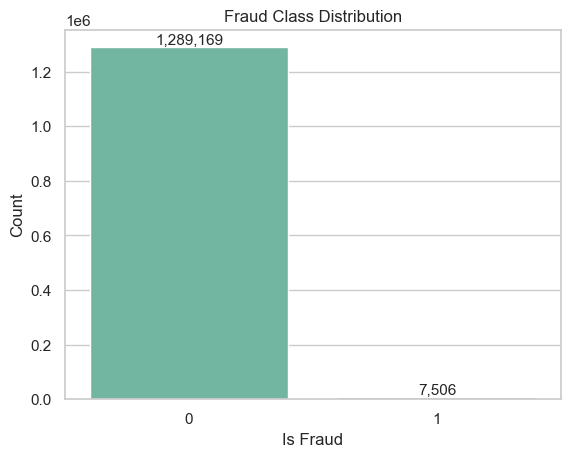

In [16]:
ax = sns.countplot(x="is_fraud", data=df, palette="Set2")

# add count labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(
        f"{count:,}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Fraud Class Distribution")
ax.set_xlabel("Is Fraud")
ax.set_ylabel("Count")
plt.show()

Text(0.5, 1.0, 'City Population vs Fraud')

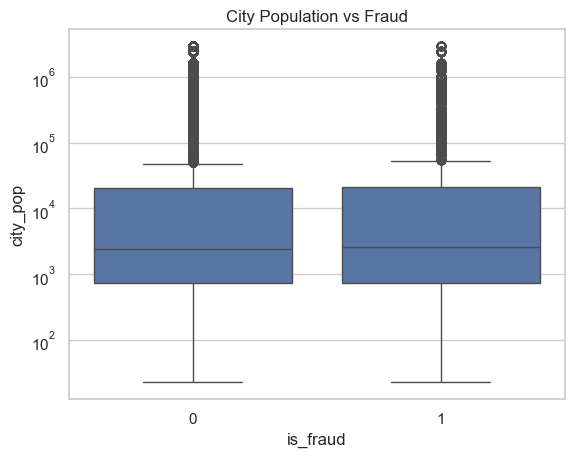

In [17]:
sns.boxplot(x="is_fraud", y="city_pop", data=df)
plt.yscale("log")
plt.title("City Population vs Fraud")

Fraud transactions are cyclical and happen mostly in the night hours between 21:00h and 04:00h

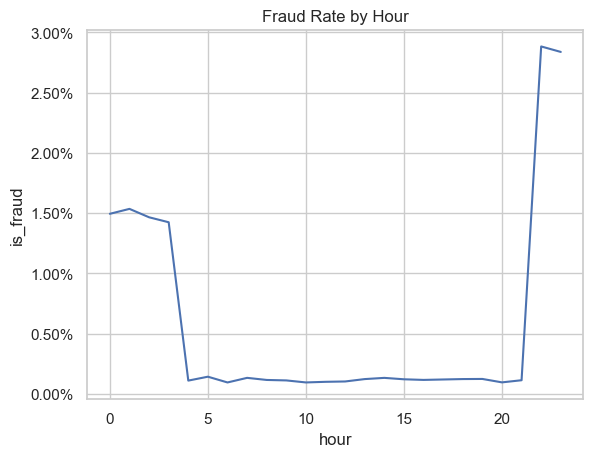

<Axes: title={'center': 'Fraud Rate by Weekday'}, xlabel='weekday'>

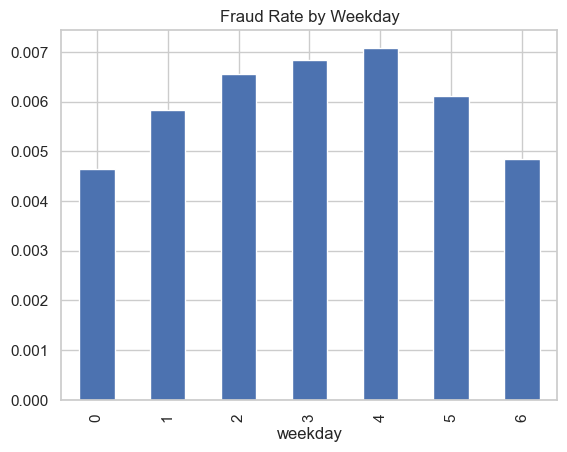

In [18]:
fraud_by_hour = (
    df.groupby("hour")["is_fraud"]
      .mean()
      .reset_index()
)

sns.lineplot(data=fraud_by_hour, x="hour", y="is_fraud")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.title("Fraud Rate by Hour")
plt.show()

(df.groupby("weekday")["is_fraud"]
   .mean()
   .plot(kind="bar", title="Fraud Rate by Weekday"))

Comparing transaction amounts by fraud status shows that fraudulent transactions tend to be
associated with higher amounts on average

C:\Users\Administrator\AppData\Local\Temp\ipykernel_22212\1191670516.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y="amt", data=df, showfliers=False, palette="Set2")


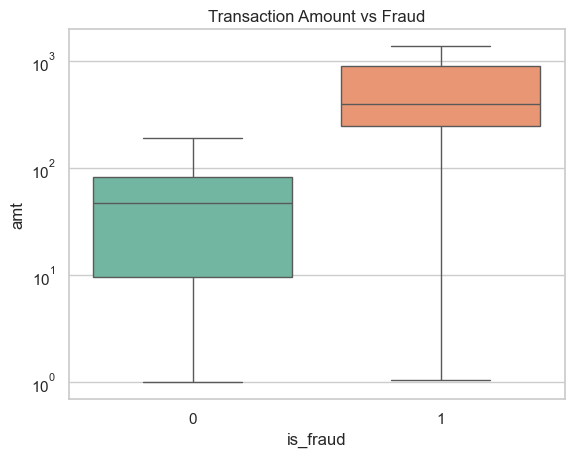

In [19]:
sns.boxplot(x="is_fraud", y="amt", data=df, showfliers=False, palette="Set2")
plt.yscale("log")
plt.title("Transaction Amount vs Fraud")
plt.show()

Some merchants show higher fraud rates

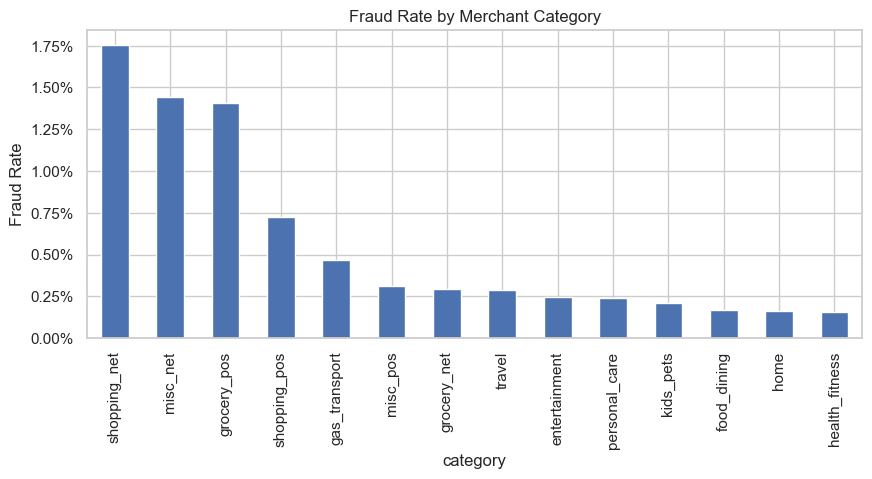

In [20]:
fraud_by_cat = (
    df.groupby("category")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
)

fraud_by_cat.plot(kind="bar", figsize=(10,4))
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.show()

In [21]:
merchant_stats = (
    df.groupby("merchant")
      .agg(
          fraud_rate=("is_fraud", "mean"),
          n_tx=("is_fraud", "count")
      )
)

merchant_stats = merchant_stats[merchant_stats["n_tx"] > 100]

merchant_stats.sort_values("fraud_rate", ascending=False).head(30)

,fraud_rate,n_tx
merchant,,
fraud_Kozey-Boehm,0.025723,1866
"fraud_Herman, Treutel and Dickens",0.025385,1300
fraud_Kerluke-Abshire,0.022307,1838
fraud_Brown PLC,0.022109,1176
fraud_Goyette Inc,0.021616,1943
fraud_Terry-Huel,0.021543,1996
fraud_Jast Ltd,0.021505,1953
"fraud_Schmeler, Bashirian and Price",0.020833,1968
fraud_Boyer-Reichert,0.019916,1908


We show a correlation heatmap

<Axes: >

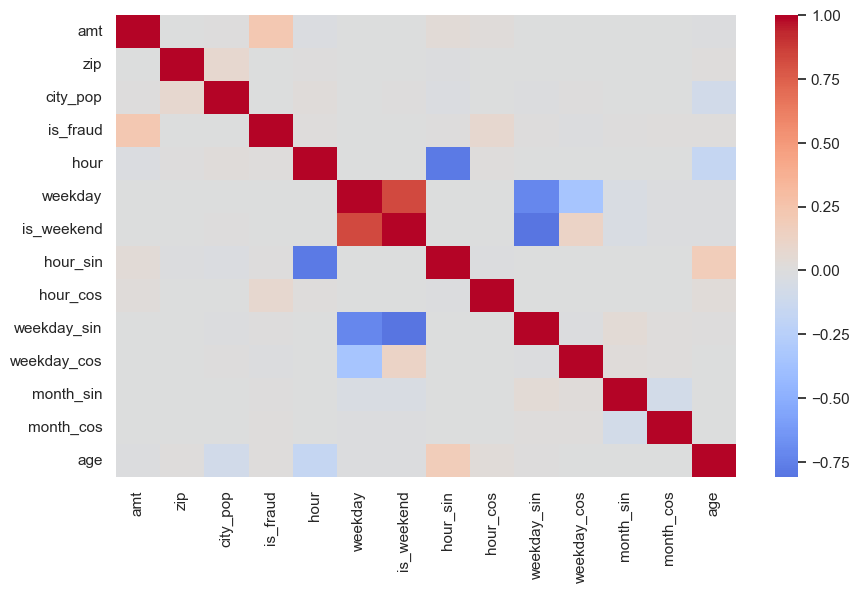

In [22]:
num_cols = df.select_dtypes(include=["int32","int64", "float64"]).columns

plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    center=0
)

In [23]:
city_counts = df["city"].value_counts()

city_counts.describe()

count     894.000000
mean     1450.419463
std       943.703719
min         7.000000
25%       533.000000
50%      1513.000000
75%      2045.000000
max      5617.000000
Name: count, dtype: float64

In [24]:
merchant_counts = df["merchant"].value_counts()

merchant_counts.describe()

count     693.000000
mean     1871.103896
std       575.359948
min       727.000000
25%      1592.000000
50%      1863.000000
75%      2345.000000
max      4403.000000
Name: count, dtype: float64

In [25]:
job_counts = df["job"].value_counts()

job_counts.describe()

count     494.000000
mean     2624.848178
std      1858.791304
min         7.000000
25%      1058.250000
50%      2087.500000
75%      3600.250000
max      9779.000000
Name: count, dtype: float64

In [26]:
state_counts = df["state"].value_counts()

state_counts.describe()

count       51.000000
mean     25425.000000
std      20081.687606
min          9.000000
25%      12046.000000
50%      22996.000000
75%      29817.000000
max      94876.000000
Name: count, dtype: float64

In [27]:
# drop raw time after EDA
df = df.drop(columns=["hour", "weekday"])


## Preprocessing and Data Split

The target variable is defined as `is_fraud`, with all remaining columns used as input features.
Features are grouped by type to enable appropriate preprocessing.

Numerical features are standardized using z-score scaling. Categorical features are split into
low-cardinality and high-cardinality groups. Low-cardinality variables are encoded using
one-hot encoding, while high-cardinality variables are encoded using target encoding to reduce
dimensionality.

All preprocessing steps are implemented using a `ColumnTransformer` to ensure consistent and
reproducible transformations.

The dataset is then split into training and validation sets, with stratification applied to
preserve the class distribution of the target variable.

In [28]:
TARGET = "is_fraud"

LOW_CARD = ["gender", "state", "category", "is_weekend"]
HIGH_CARD = ["merchant", "job", "city", "zip"]

NUM_COLS = [
    "amt",
    "city_pop",
    "age",
    "hour_sin", "hour_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_COLS),
        ("low_cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ), LOW_CARD),
        ("high_cat", TargetEncoder(
            smooth="auto",
            target_type="binary"
        ), HIGH_CARD),
    ],
    remainder="drop",
)

In [29]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

#Split training to traing/validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Training

Models are trained on the training set, while hyperparameters are selected based on
performance on the validation set.

## SVM

### Gridsearch Parameter C

We test whether the parameter C has any effect

In [30]:
C_GRID = [0.01, 0.1, 1, 10, 100, 1000]

rows = []

for C in C_GRID:
    print("\n" + "="*70)
    print(f"C = {C}")

    svm_linear = CalibratedClassifierCV(
        LinearSVC(C=C, class_weight="balanced", random_state=42)
    )

    svm_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("svm", svm_linear)
    ])

    svm_pipe.fit(X_train, y_train)

    y_pred = svm_pipe.predict(X_val)
    y_proba = svm_pipe.predict_proba(X_val)[:, 1]

    print("\nclassification_report")
    print(classification_report(y_val, y_pred))

    roc = roc_auc_score(y_val, y_proba)
    pr  = average_precision_score(y_val, y_proba)

    print(f"ROC AUC: {roc:.6f}")
    print(f"PR  AUC: {pr:.6f}")

    rows.append({
        "C": C,
        "ROC_AUC": roc,
        "PR_AUC": pr
    })

results = pd.DataFrame(rows).sort_values("C")
results


C = 0.01

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.53      0.10      0.17      1501

    accuracy                           0.99    259335
   macro avg       0.76      0.55      0.59    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC: 0.954067
PR  AUC: 0.366455

C = 0.1

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.52      0.10      0.17      1501

    accuracy                           0.99    259335
   macro avg       0.76      0.55      0.59    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC: 0.955199
PR  AUC: 0.374995

C = 1

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.52      0.10      0.17      1501

    accuracy   

,C,ROC_AUC,PR_AUC
0,0.01,0.954067,0.366455
1,0.10,0.955199,0.374995
2,1.00,0.955233,0.375976
3,10.00,0.955353,0.376898
4,100.00,0.955313,0.377363
5,1000.00,0.955318,0.376901


In [31]:
summary = results.copy()

base_roc = summary.loc[summary["C"] == 1, "ROC_AUC"].iloc[0]
base_pr  = summary.loc[summary["C"] == 1, "PR_AUC"].iloc[0]

summary["ROC_delta_vs_C1"] = summary["ROC_AUC"] - base_roc
summary["PR_delta_vs_C1"]  = summary["PR_AUC"]  - base_pr

summary

,C,ROC_AUC,PR_AUC,ROC_delta_vs_C1,PR_delta_vs_C1
0,0.01,0.954067,0.366455,-0.001166,-0.009521
1,0.10,0.955199,0.374995,-0.000034,-0.000981
2,1.00,0.955233,0.375976,0.000000,0.000000
3,10.00,0.955353,0.376898,0.000120,0.000922
4,100.00,0.955313,0.377363,0.000079,0.001387
5,1000.00,0.955318,0.376901,0.000085,0.000924


We plot the performance to visualize that tuning C has minimal effects

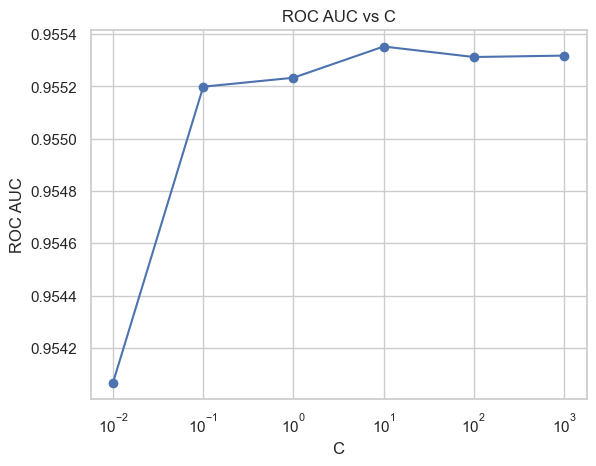

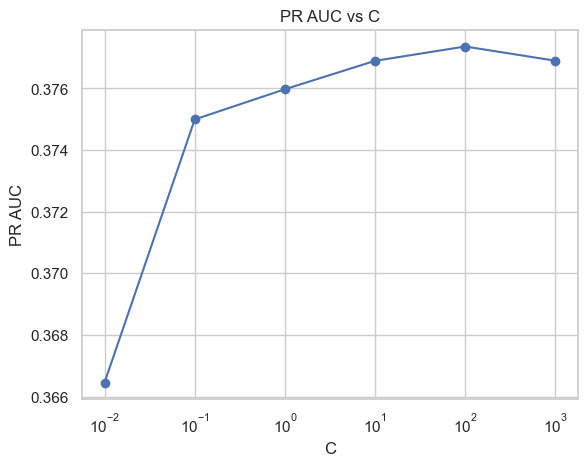

In [32]:
plt.figure()
plt.plot(results["C"], results["ROC_AUC"], marker="o")
plt.xscale("log")
plt.title("ROC AUC vs C")
plt.xlabel("C")
plt.ylabel("ROC AUC")
plt.show()

plt.figure()
plt.plot(results["C"], results["PR_AUC"], marker="o")
plt.xscale("log")
plt.title("PR AUC vs C")
plt.xlabel("C")
plt.ylabel("PR AUC")
plt.show()

### Gridsearch class_weight

We test whether the class_weight parameter has any effects.

In [33]:
# Different weights for the fraud class
# Based on imbalance ratio ~172:1
WEIGHT_GRID = [
    "balanced",
    {0: 1, 1: 50},
    {0: 1, 1: 100},
    {0: 1, 1: 172},
    {0: 1, 1: 250},
    {0: 1, 1: 350},
]

rows = []

for weight in WEIGHT_GRID:
    print("\n" + "="*70)
    print(f"class_weight = {weight}")

    svm_linear = CalibratedClassifierCV(
        LinearSVC(C=1.0, class_weight=weight, random_state=42)
    )

    svm_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("svm", svm_linear)
    ])

    svm_pipe.fit(X_train, y_train)

    y_pred = svm_pipe.predict(X_val)
    y_proba = svm_pipe.predict_proba(X_val)[:, 1]

    print("\nclassification_report")
    print(classification_report(y_val, y_pred))

    roc = roc_auc_score(y_val, y_proba)
    pr  = average_precision_score(y_val, y_proba)

    print(f"ROC AUC: {roc:.6f}")
    print(f"PR  AUC: {pr:.6f}")

    # Label for DataFrame
    weight_label = "balanced" if weight == "balanced" else f"1:{weight[1]}"
    
    rows.append({
        "class_weight": weight_label,
        "ROC_AUC": roc,
        "PR_AUC": pr
    })

results_weight = pd.DataFrame(rows)
results_weight


class_weight = balanced

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.53      0.10      0.17      1501

    accuracy                           0.99    259335
   macro avg       0.76      0.55      0.59    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC: 0.955274
PR  AUC: 0.376275

class_weight = {0: 1, 1: 50}

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.50      0.10      0.17      1501

    accuracy                           0.99    259335
   macro avg       0.75      0.55      0.58    259335
weighted avg       0.99      0.99      0.99    259335

ROC AUC: 0.949610
PR  AUC: 0.401838

class_weight = {0: 1, 1: 100}

classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
          

,class_weight,ROC_AUC,PR_AUC
0,balanced,0.955274,0.376275
1,1:50,0.949610,0.401838
2,1:100,0.953454,0.391861
3,1:172,0.955259,0.375838
4,1:250,0.956137,0.361936
5,1:350,0.956570,0.345743


Effects on the parameter are neglectable or deteriorate performance compared to the baseline "balanced"

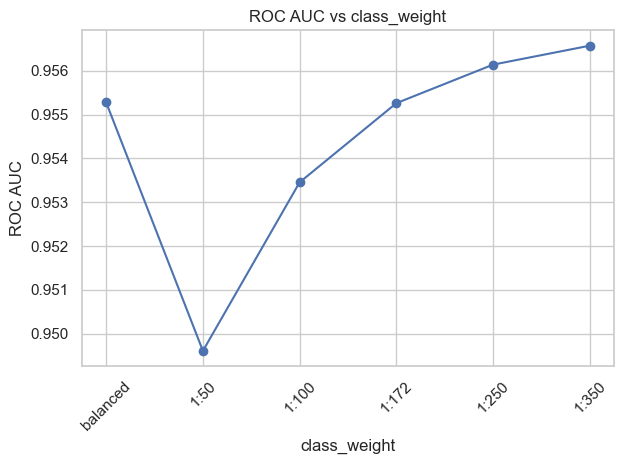

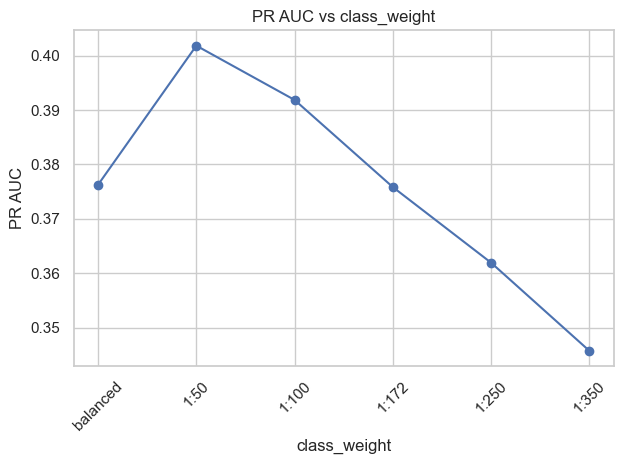

In [34]:
plt.figure()
plt.plot(results_weight["class_weight"], results_weight["ROC_AUC"], marker="o")
plt.title("ROC AUC vs class_weight")
plt.xlabel("class_weight")
plt.ylabel("ROC AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(results_weight["class_weight"], results_weight["PR_AUC"], marker="o")
plt.title("PR AUC vs class_weight")
plt.xlabel("class_weight")
plt.ylabel("PR AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Threshold Tuning and Validation

After training the calibrated Linear SVM on the training set, predicted fraud probabilities
are obtained for the validation set. Model performance is first evaluated using the default
decision threshold of 0.5 to establish a baseline.

To better account for the asymmetric costs of fraud detection, the decision threshold is then
optimized on the validation set using the precision–recall curve. The optimal threshold is
selected by maximizing the F₂-score, which places greater emphasis on recall.

In [35]:
svm_linear = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=42)  # C default = 1.0
)

svm_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("svm", svm_linear)
])

svm_pipe.fit(X_train, y_train)

# Validation probabilities
y_proba_val = svm_pipe.predict_proba(X_val)[:, 1]

In [36]:
# Baseline at threshold 0.5

thr_default = 0.5
y_pred_default = (y_proba_val >= thr_default).astype(int)

print("Baseline (threshold = 0.5) on Validation")
print(classification_report(y_val, y_pred_default))

print("ROC-AUC:", roc_auc_score(y_val, y_proba_val))
print("PR-AUC :", average_precision_score(y_val, y_proba_val))

Baseline (threshold = 0.5) on Validation
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.52      0.10      0.17      1501

    accuracy                           0.99    259335
   macro avg       0.76      0.55      0.59    259335
weighted avg       0.99      0.99      0.99    259335

ROC-AUC: 0.9552892027782497
PR-AUC : 0.3769503545227707


In [37]:
# Threshold tuning via Precision Recall Curve
# Goal: Best F2 (Recall is weighted more heavily)

prec, rec, thr = precision_recall_curve(y_val, y_proba_val)

# thr has length len(prec)-1, so align properly
prec2 = prec[:-1]
rec2  = rec[:-1]

beta = 2.0
f2 = (1 + beta**2) * (prec2 * rec2) / (beta**2 * prec2 + rec2 + 1e-12)

best_idx = int(np.argmax(f2))
best_thr_svm = float(thr[best_idx])

print("Best threshold by F2 on Validation:", best_thr_svm)
print("Precision:", float(prec2[best_idx]))
print("Recall   :", float(rec2[best_idx]))
print("F2       :", float(f2[best_idx]))

Best threshold by F2 on Validation: 0.025406233825296776
Precision: 0.34123563218390807
Recall   : 0.6329113924050633
F2       : 0.5405097860716457


In [38]:
# Classification_report() with tuned threshold

y_pred_tuned = (y_proba_val >= best_thr_svm).astype(int)

print(f"Threshold tuned (F2-opt) on Validation, thr = {best_thr_svm:.6f}")
print(classification_report(y_val, y_pred_tuned))

print("ROC-AUC:", roc_auc_score(y_val, y_proba_val))
print("PR-AUC :", average_precision_score(y_val, y_proba_val))

Threshold tuned (F2-opt) on Validation, thr = 0.025406
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.34      0.63      0.44      1501

    accuracy                           0.99    259335
   macro avg       0.67      0.81      0.72    259335
weighted avg       0.99      0.99      0.99    259335

ROC-AUC: 0.9552892027782497
PR-AUC : 0.3769503545227707


In [ ]:
# Optional: Recall target, e.g. at least 0.80
# then we could choose the smallest threshold that achieves recall >= target.
target_recall = 0.80

# recall typically drops with higher threshold, so search for candidates
mask = rec2 >= target_recall
if mask.any():
    idx = np.where(mask)[0][-1]  # highest threshold that still achieves recall
    thr_recall = float(thr[idx])
    print("Threshold for recall >= target:", thr_recall)
    print("Precision:", float(prec2[idx]))
    print("Recall   :", float(rec2[idx]))
else:
    thr_recall = None
    print("Target recall not reachable with this model on Validation.")

Threshold for recall >= target: 0.011464147694229324
Precision: 0.0729514669258337
Recall   : 0.8001332445036642


In [40]:
# Classification_report() for recall target threshold (if available)

if thr_recall is not None:
    y_pred_recall = (y_proba_val >= thr_recall).astype(int)
    print(f"Threshold tuned (recall target) on Validation, thr = {thr_recall:.6f}")
    print(classification_report(y_val, y_pred_recall))
    print("ROC-AUC:", roc_auc_score(y_val, y_proba_val))
    print("PR-AUC:", average_precision_score(y_val, y_proba_val))

Threshold tuned (recall target) on Validation, thr = 0.011464
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    257834
           1       0.07      0.80      0.13      1501

    accuracy                           0.94    259335
   macro avg       0.54      0.87      0.55    259335
weighted avg       0.99      0.94      0.96    259335

ROC-AUC: 0.9552892027782497
PR-AUC: 0.3769503545227707


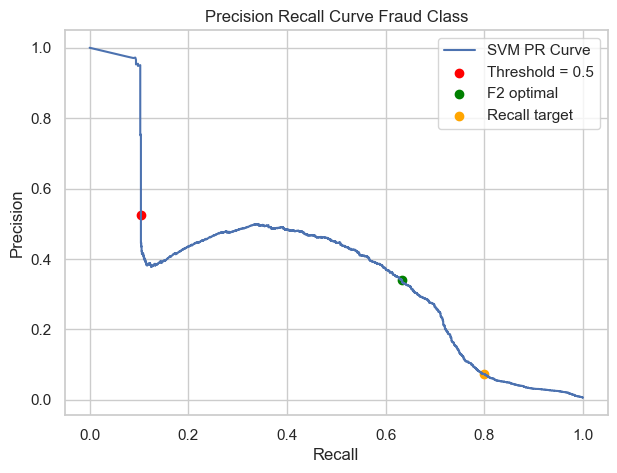

In [41]:
# Precision Recall Curve for Fraud Class

# Precision Recall points from probabilities
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label="SVM PR Curve")

# Mark default threshold 0.5
idx_05 = np.argmin(np.abs(thr - 0.5))
plt.scatter(rec[idx_05], prec[idx_05], color="red", label="Threshold = 0.5")

# Mark F2 optimized threshold
idx_f2 = np.argmin(np.abs(thr - best_thr_svm))
plt.scatter(rec[idx_f2], prec[idx_f2], color="green", label="F2 optimal")

# Mark recall target threshold
if thr_recall is not None:
    idx_rec = np.argmin(np.abs(thr - thr_recall))
    plt.scatter(rec[idx_rec], prec[idx_rec], color="orange", label="Recall target")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve Fraud Class")
plt.legend()
plt.grid(True)
plt.show()

## Random Forest Training and Hyperparameter Tuning

A Random Forest classifier is trained using a predefined grid of hyperparameter configurations.
The grid varies the number of trees, tree depth, minimum samples per leaf, and the number of
features considered at each split.

We also train for different class_weight configurations to see whether it has any positive effects on evaluation metrics. 

Model performance is evaluated using ROC-AUC and PR-AUC, and results are compared across
configurations. The final model configuration is selected based on validation performance.

In [42]:
RF_GRID = [
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 20,   "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 10,   "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1,  "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 10, "max_features": 0.3},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 10, "max_features": 0.5},
]

rows = []

for params in RF_GRID:
    print("\n" + "="*70)
    print("RF params:", params)

    rf = RandomForestClassifier(
        **params,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("rf", rf)
    ])

    rf_pipe.fit(X_train, y_train)

    y_pred = rf_pipe.predict(X_val)
    y_proba = rf_pipe.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_proba)
    pr  = average_precision_score(y_val, y_proba)

    print(classification_report(y_val, y_pred))
    print(f"ROC AUC: {roc:.6f}")
    print(f"PR  AUC: {pr:.6f}")

    rows.append({
        **params,
        "ROC_AUC": roc,
        "PR_AUC": pr
    })

rf_results = pd.DataFrame(rows).sort_values(["PR_AUC","ROC_AUC"], ascending=False)
rf_results



RF params: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.84      0.81      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.92      0.91    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC: 0.996686
PR  AUC: 0.893286

RF params: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.84      0.81      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.92      0.91    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC: 0.996642
PR  AUC: 0.894761

RF params: {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1

,n_estimators,max_depth,min_samples_leaf,max_features,ROC_AUC,PR_AUC
7,300,NaN,10,0.5,0.998508,0.926517
5,300,NaN,1,sqrt,0.994646,0.922457
6,300,NaN,10,0.3,0.998462,0.919801
4,300,NaN,5,sqrt,0.997042,0.904437
1,500,NaN,10,sqrt,0.996642,0.894761
0,300,NaN,10,sqrt,0.996686,0.893286
2,300,20.0,10,sqrt,0.994660,0.876398
3,300,10.0,10,sqrt,0.987548,0.804283


Like in SVM we see that class weight tuning has minimal effect

In [43]:
WEIGHT_GRID = [
    None,
    "balanced",
    {0: 1, 1: 10},
    {0: 1, 1: 50},
    {0: 1, 1: 100},
    {0: 1, 1: 172},
]

rows = []

for w in WEIGHT_GRID:
    print("\n" + "="*70)
    print(f"class_weight = {w}")

    rf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        max_depth=None,
        max_features="sqrt",
        class_weight=w,
        n_jobs=-1,
        random_state=42
    )

    rf_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("rf", rf)
    ])

    rf_pipe.fit(X_train, y_train)

    y_pred = rf_pipe.predict(X_val)
    y_proba = rf_pipe.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_proba)
    pr  = average_precision_score(y_val, y_proba)

    label = "None" if w is None else ("balanced" if w == "balanced" else f"1:{w[1]}")
    rows.append({"class_weight": label, "ROC_AUC": roc, "PR_AUC": pr})

rf_weight_results = pd.DataFrame(rows)
rf_weight_results


class_weight = None

class_weight = balanced

class_weight = {0: 1, 1: 10}

class_weight = {0: 1, 1: 50}

class_weight = {0: 1, 1: 100}

class_weight = {0: 1, 1: 172}


,class_weight,ROC_AUC,PR_AUC
0,None,0.995088,0.878320
1,balanced,0.996687,0.893027
2,1:10,0.995720,0.885322
3,1:50,0.996603,0.892344
4,1:100,0.996620,0.893442
5,1:172,0.996431,0.893707


As in the SVM setup, the decision threshold is tuned on the validation set by maximizing the F₂-score.

In [44]:
# Fit best RF model first
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    max_depth=None,
    max_features=0.5,
    class_weight=None,
    n_jobs=-1,
    random_state=42
)

rf_base = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf)
])

rf_base.fit(X_train, y_train)

y_proba_val = rf_base.predict_proba(X_val)[:, 1]

# Baseline at 0.5
thr_default = 0.5
y_pred_default = (y_proba_val >= thr_default).astype(int)

print("Baseline (threshold=0.5) on Validation")
print(classification_report(y_val, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_val))
print("PR-AUC :", average_precision_score(y_val, y_proba_val))

# Tune threshold via F2
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)
prec2, rec2 = prec[:-1], rec[:-1]

beta = 2.0
f2 = (1 + beta**2) * (prec2 * rec2) / (beta**2 * prec2 + rec2 + 1e-12)

best_idx = int(np.argmax(f2))
best_thr_rf = float(thr[best_idx])

print("Best threshold by F2 on Validation:", best_thr_rf)
print("Precision:", float(prec2[best_idx]))
print("Recall   :", float(rec2[best_idx]))
print("F2       :", float(f2[best_idx]))

y_pred_tuned = (y_proba_val >= best_thr_rf).astype(int)
print(f"Threshold tuned (F2-opt) on Validation, thr={best_thr_rf:.6f}")
print(classification_report(y_val, y_pred_tuned))

# Optional: recall target
target_recall = 0.80
mask = rec2 >= target_recall
if mask.any():
    idx = np.where(mask)[0][-1]
    thr_recall = float(thr[idx])
    print("Threshold for recall >= target:", thr_recall)
    print("Precision:", float(prec2[idx]))
    print("Recall   :", float(rec2[idx]))
    y_pred_recall = (y_proba_val >= thr_recall).astype(int)
    print(classification_report(y_val, y_pred_recall))
else:
    print("Target recall not reachable on Validation.")

Baseline (threshold=0.5) on Validation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.96      0.78      0.86      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.89      0.93    259335
weighted avg       1.00      1.00      1.00    259335

ROC-AUC: 0.9978132811821036
PR-AUC : 0.9277655031105324
Best threshold by F2 on Validation: 0.19619591134522893
Precision: 0.8084455324357405
Recall   : 0.8800799467021986
F2       : 0.8647551715106565
Threshold tuned (F2-opt) on Validation, thr=0.196196
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.81      0.88      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.90      0.94      0.92    259335
weighted avg       1.00      1.00      1.00    259335

Threshold for recall >= target: 0.44972652554440723


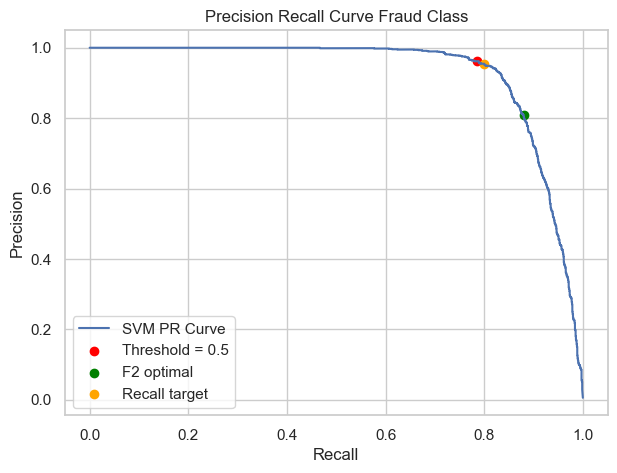

In [45]:
# Precision Recall Curve for Fraud Class

# Precision Recall points from probabilities
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label="SVM PR Curve")

# Mark default threshold 0.5
idx_05 = np.argmin(np.abs(thr - 0.5))
plt.scatter(rec[idx_05], prec[idx_05], color="red", label="Threshold = 0.5")

# Mark F2 optimized threshold
idx_f2 = np.argmin(np.abs(thr - best_thr_rf))
plt.scatter(rec[idx_f2], prec[idx_f2], color="green", label="F2 optimal")

# Mark recall target threshold
if thr_recall is not None:
    idx_rec = np.argmin(np.abs(thr - thr_recall))
    plt.scatter(rec[idx_rec], prec[idx_rec], color="orange", label="Recall target")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve Fraud Class")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
y_pred = rf_base.predict(X_val)
y_proba = rf_base.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("PR-AUC:", average_precision_score(y_val, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.96      0.78      0.86      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.89      0.93    259335
weighted avg       1.00      1.00      1.00    259335

ROC-AUC: 0.9978132811821033
PR-AUC: 0.9277655031105324


# Test

We now load the test set to evaluate the baseline models, which serve as a reference for
comparison against SMOTE-enhanced models.

In [47]:
df_test  = pd.read_csv(DATA_DIR / "fraudTest.csv")
df_test  = feature_engineering(df_test)
df_test = df_test.drop(columns=["hour", "weekday"])



X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET]


## SVM

In [48]:
y_pred_svm = (svm_pipe.predict_proba(X_test)[:, 1] >= best_thr_svm).astype(int)
y_proba_svm = svm_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_svm))
print("PR-AUC:", average_precision_score(y_test, y_proba_svm))

# threshold-dependent classification report (F2-opt threshold)
y_pred_svm_thr = (y_proba_svm >= best_thr_svm).astype(int)
print(f"\nclassification_report (F2 threshold = {best_thr_svm:.6f})")
print(classification_report(y_test, y_pred_svm_thr))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.18      0.38      0.24      2145

    accuracy                           0.99    555719
   macro avg       0.59      0.69      0.62    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.9030786980231861
PR-AUC: 0.10139099780659461

classification_report (F2 threshold = 0.025406)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.18      0.38      0.24      2145

    accuracy                           0.99    555719
   macro avg       0.59      0.69      0.62    555719
weighted avg       0.99      0.99      0.99    555719



## Random Forest

In [49]:
y_proba = rf_base.predict_proba(X_test)[:, 1]

# threshold-independent metrics
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

# threshold-dependent classification report (F2-opt threshold)
y_pred = (y_proba >= best_thr_rf).astype(int)
print(f"\nclassification_report (F2 threshold = {best_thr_rf:.6f})")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9817268360059388
PR-AUC : 0.5085210054413383

classification_report (F2 threshold = 0.196196)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.59      0.41      0.48      2145

    accuracy                           1.00    555719
   macro avg       0.79      0.70      0.74    555719
weighted avg       1.00      1.00      1.00    555719



In [50]:
y_pred_rf = rf_base.predict(X_test)
y_proba_rf = rf_base.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.86      0.31      0.45      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.65      0.73    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9817268360059387
PR-AUC: 0.5085210054413382


## SMOTE
The SMOTE-enhanced models are evaluated on the test set as the
baseline models, enabling a direct and fair comparison of performance.

In [51]:
svm_linear = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=42)
)

svm_pipe_sm = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(
        sampling_strategy="auto",
        k_neighbors=5,
        random_state=42
    )),
    ("svm", svm_linear)
])

svm_pipe_sm.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt', 'city_pop', 'age',
                                                   'hour_sin', 'hour_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'month_sin', 'month_cos']),
                                                 ('low_cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'state',
                                                   'category', 'is_weekend']),
                                                 ('high_cat',
                                                  TargetEncoder(target_type='binary'),
                                                  ['merchant', 'job', 'city',
                                                   'zip'])])),
                ('smote', SMOTE(random_state=42)),
                ('svm',
                 CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                                            random_state=42)))])

In [52]:
y_pred_svm_sm = svm_pipe_sm.predict(X_test)
y_proba_svm_sm = svm_pipe_sm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_svm_sm))
print("PR-AUC:", average_precision_score(y_test, y_proba_svm_sm))

# threshold-dependent classification report (F2-opt threshold)
y_pred_svm_sm_thr = (y_proba_svm_sm >= best_thr_svm).astype(int)
print(f"\nclassification_report (F2 threshold = {best_thr_svm:.6f})")
print(classification_report(y_test, y_pred_svm_sm_thr))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    553574
           1       0.03      0.68      0.06      2145

    accuracy                           0.91    555719
   macro avg       0.51      0.80      0.50    555719
weighted avg       0.99      0.91      0.95    555719

ROC-AUC: 0.8971056939317732
PR-AUC: 0.0856547916453208

classification_report (F2 threshold = 0.025406)
              precision    recall  f1-score   support

           0       1.00      0.37      0.54    553574
           1       0.01      0.98      0.01      2145

    accuracy                           0.37    555719
   macro avg       0.50      0.67      0.27    555719
weighted avg       1.00      0.37      0.53    555719



In [53]:
rf_sm = Pipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(
        sampling_strategy="auto",
        k_neighbors=5,
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        max_depth=None,
        max_features=0.5,
        class_weight=None,
        n_jobs=-1,
        random_state=42
    ))
])

rf_sm.fit(X_train, y_train)

y_pred_rf_sm = rf_sm.predict(X_test)
y_proba_rf_sm = rf_sm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_sm))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf_sm))

# threshold-dependent classification report (F2-opt threshold)
y_pred_rf_sm_thr = (y_proba_rf_sm >= best_thr_rf).astype(int)
print(f"\nclassification_report (F2 threshold = {best_thr_rf:.6f})")
print(classification_report(y_test, y_pred_rf_sm_thr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.20      0.10      0.14      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.55      0.57    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.8143125296510392
PR-AUC: 0.1014070838575286

classification_report (F2 threshold = 0.196196)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.10      0.19      0.13      2145

    accuracy                           0.99    555719
   macro avg       0.55      0.59      0.56    555719
weighted avg       0.99      0.99      0.99    555719



## Statistical Significance

To assess whether SMOTE leads to a statistically significant **difference** in fraud detection
performance, a McNemar-style test is conducted on the held-out test set. The test focuses
exclusively on true fraud cases and evaluates whether fraud recall differs between the baseline
model and the SMOTE-enhanced model.

In [54]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_fraud_recall(y_true, y_pred_no_smote, y_pred_smote, pos_label=1):
    """
    McNemar-style test on POSITIVE (fraud) cases only.
    Tests whether fraud recall differs significantly between two models
    on a single held-out test set.

    Returns:
      b: # fraud cases missed by no-SMOTE but caught by SMOTE
      c: # fraud cases caught by no-SMOTE but missed by SMOTE
      p: p-value (exact if b+c<20 else chi-square w/ continuity correction)
    """
    y_true = np.asarray(y_true)
    a = np.asarray(y_pred_no_smote)
    bpred = np.asarray(y_pred_smote)

    # Only look at true fraud cases
    mask = (y_true == pos_label)

    # On fraud cases, "correct" means predicting fraud (TP)
    a_correct = (a[mask] == pos_label)
    b_correct = (bpred[mask] == pos_label)

    # Discordant pairs
    # b_count: SMOTE correct, no-SMOTE wrong (SMOTE improves recall)
    b_count = int(np.sum((~a_correct) & ( b_correct)))
    # c_count: no-SMOTE correct, SMOTE wrong (SMOTE hurts recall)
    c_count = int(np.sum(( a_correct) & (~b_correct)))

    table = [[0, c_count],
             [b_count, 0]]

    use_exact = (b_count + c_count) < 20
    res = mcnemar(table, exact=use_exact, correction=not use_exact)

    return {
        "b": b_count,
        "c": c_count,
        "table": table,
        "stat": float(res.statistic),
        "p_value": float(res.pvalue),
        "exact": use_exact
    }

out_rf = mcnemar_fraud_recall(y_test, y_pred_rf, y_pred_rf_sm)
print(out_rf)

out_svm = mcnemar_fraud_recall(y_test, y_pred_svm, y_pred_svm_sm)
print(out_svm)

{'b': 12, 'c': 453, 'table': [[0, 453], [12, 0]], 'stat': 416.3440860215054, 'p_value': 1.524780648608112e-92, 'exact': False}
{'b': 647, 'c': 0, 'table': [[0, 0], [647, 0]], 'stat': 645.001545595054, 'p_value': 2.7301274097203196e-142, 'exact': False}


In [ ]:
# === Export per-row test predictions for downstream comparison ===
# Run this cell ONCE after running all preceding cells. It writes a parquet
# file used by scripts/evaluate.py to compute McNemar tests against the LSTM.

import pandas as pd
from pathlib import Path

OUT = Path("../../data/processed/legacy_predictions.parquet")
OUT.parent.mkdir(parents=True, exist_ok=True)

cols = {"y_true": y_test.to_numpy().astype(int)}
for name, label_var, proba_var in [
    ("svm", "y_pred_svm", "y_proba_svm"),
    ("rf", "y_pred_rf", "y_proba_rf"),
    ("svm_smote", "y_pred_svm_sm", "y_proba_svm_sm"),
    ("rf_smote", "y_pred_rf_sm", "y_proba_rf_sm"),
]:
    if proba_var in globals():
        cols[name] = np.asarray(globals()[proba_var]).astype(float)
    elif label_var in globals():
        cols[name] = np.asarray(globals()[label_var]).astype(int)
    else:
        print(f"warning: {label_var}/{proba_var} not found; skipping {name}")

pd.DataFrame(cols).to_parquet(OUT)
print(f"Wrote {OUT.resolve()} with {len(cols)} columns and {len(cols['y_true'])} rows")
